In [3]:
import numpy as np
import gymnasium as gym
from tqdm import tqdm
import matplotlib.pyplot as plt
import time


class taxi_driver:
    def __init__(self, alpha=1, epsilon=0.1, gamma=0.99):
        self.alpha = alpha
        self.epsilon = epsilon
        self.gamma = gamma

    def argmax(self, q_values):
        top_value = float('-inf')
        ties = []

        for i in range(len(q_values)):
            if q_values[i] > top_value:
                ties = []
                top_value = q_values[i]
                ties.append(i)
            elif q_values[i] == top_value:
                ties.append(i)
        
        return np.random.choice(ties)

    def greedy_action_selection(self, Q_state):

        return self.argmax(Q_state)

    def epsilon_greedy_action_selection(self, Q_state):
        if np.random.rand() < self.epsilon:
            return np.random.randint(len(Q_state))  # Explore : Quanto maior Epsilon mais o agente explora ações novas.
        else:
            return self.argmax(Q_state)  # Exploit : Quanto menor o Epsilon mais o agente se aproveita da melhor ação até o momento.


    def incremental_update(self, Q, state, action, reward, next_state, done):
        if done:
            target = reward
        else:
            target = reward + self.gamma * np.max(Q[next_state])

        Q[state][action] = Q[state][action] + self.alpha * (target - Q[state][action])

        return Q

    def run_algorithm(self):
        steps = 1000
        runs = 2000

        average_rewards = np.zeros(steps, dtype=float)

        for run in tqdm(range(runs)):
            env = gym.make("Taxi-v3")

            
            obs, info = env.reset()

            n_states = env.observation_space.n    
            n_actions = env.action_space.n

            # agora Q depende do estado: Q[s][a]
            Q = np.zeros((n_states, n_actions), dtype=float)
            Times = np.zeros(n_actions, dtype=int)

            Rewards = np.zeros(steps, dtype=float)

            step = 0
            while step < steps:
                action = self.epsilon_greedy_action_selection(Q[obs])

                next_obs, reward, terminated, truncated, info = env.step(action)
                done = terminated or truncated

                Times[action] += 1

                Q = self.incremental_update(Q, state=obs, action=action,
                                            reward=reward, next_state=next_obs, done=done)

                Rewards[step] = reward
                obs = next_obs
                step += 1

                if done:
                    obs, info = env.reset()

            env.close()
            average_rewards += Rewards
            last_Q = Q
        average_rewards /= runs
        return average_rewards, last_Q 
    
    def plot(self, average_rewards):
        
        plt.plot(average_rewards, label = "Sample Average")
        plt.xlabel("Steps")
        plt.ylabel("Average Reward")
        plt.title("Average Reward over Steps")
        plt.legend()
        plt.show()
        
    def view(self, Q, episodes=3, max_steps=200, sleep=0.05):
        env = gym.make("Taxi-v3", render_mode="human")
        for ep in range(episodes):
            obs, info = env.reset()
            total = 0.0

            for _ in range(max_steps):
                action = self.greedy_action_selection(Q[obs])  # sem epsilon (só melhor ação)
                obs, reward, terminated, truncated, info = env.step(action)
                total += reward
                time.sleep(sleep)

                if terminated or truncated:
                    break

            print(f"Episódio {ep+1}: retorno = {total}")

        env.close()

100%|██████████| 2000/2000 [01:59<00:00, 16.80it/s]


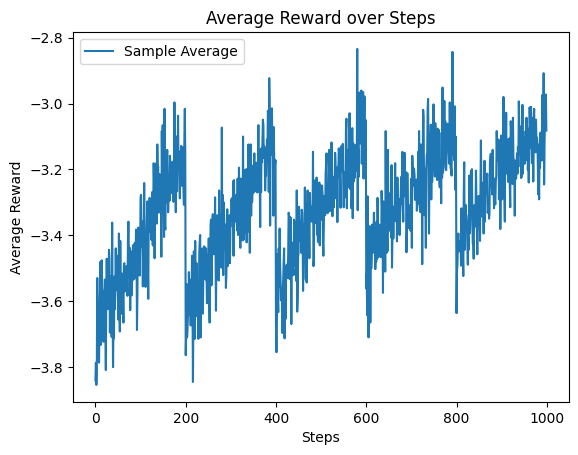

In [4]:
### teste código
taxi = taxi_driver(alpha=0.3, epsilon=0.4, gamma=0.99)

average_reward, Q = taxi.run_algorithm()
taxi.plot(average_reward)


In [15]:
taxi.view(Q, episodes=3, sleep=0.05)

Episódio 1: retorno = -749.0


KeyboardInterrupt: 